<a href="https://colab.research.google.com/github/manika-lamba/SP26-LIS4_5693/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Supervised Machine Learning

In this lab assignment, we will learn to perform supervised machine learning using `sklearn` library. I would highly recommend that you go through its documentation to learn more about performing different types of ML tasks like classification, regression, clustering, model selection and dimensionality reduction here: https://scikit-learn.org/stable/


*Note: Before starting this lab assignment, please complete the Introduction to Machine Learning notebook*

## Leaning Objectives

In this exercise, you will:

- Load and process the assigned data file
- Identify `features` and `target` labels for your dataset
- Split your data into test and training sets
- Perform text-preprocessing
- Compare different classifiers' performances based on their evaluation metrics (accuracy, precision, recall, f1-score) and pick the best one for your dataset
- Visualize the confusion matrix results
- Finally, use the classifier to run on unseen (new) data to make predictions


This exercise builds directly on concepts from discussed in the precursor notebook on "Introduction to Machine Learning".

## Install and Load Libraries

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Load and read your file from GitHub

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-4/data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

Let's save it as a DataFrame using `df` variable that holds pandas DataFrame and see how it looks!

As you can see, this dataset consists of metadata for journal articles published in gender and politics related journals.

In [3]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

                      AU                                                 DE  \
0               KILLEN K  MOTHERHOOD; RACE; RECOGNITION; POLITICAL RESIS...   
1  HIRSCHMANN N;REGIER E  MARY WOLLSTONECRAFT; FREEDOM; SOCIAL CONSTRUCT...   
2      MAHONEY A;CLARK C  LEGISLATIVE POLITICS; COLLECTIVE ACTION; GENDE...   
3              SETZLER M  FEMALE LEADERS; SURVEY METHODS; SOCIAL DESIRAB...   
4  HUNT K;GRUSZCZYNSKI M          TREATIES; CEDAW; WOMEN'S RIGHTS; ABORTION   

                                                  ID  \
0                                              WOMEN   
1                                                NaN   
2  SUBSTANTIVE REPRESENTATION; CRITICAL MASS; GEN...   
3  SOCIAL DESIRABILITY; GENDER STEREOTYPES; SUPPO...   
4  INTERNATIONAL HUMAN-RIGHTS; TREATIES; IMPACT; ...   

                                                  C1  \
0  KILLEN, K (CORRESPONDING AUTHOR), UNIV COLORAD...   
1  HIRSCHMANN, NJ (CORRESPONDING AUTHOR), UNIV PE...   
2  MAHONEY, AM (CORR

Now, we will Split our data into **features** and **target** labels.

This dataset was part of one of my research projects, where we added a new column **"code_choice"** and the annotators manually added if the article was related to gender research or not based on the **"abstract"** for those articles.

For this dataset, as I mentioned above our features will be **Abstract** and target will be **code_choices**

In [4]:
features = df['AB']
target = df['code_choice']

Below, I am renaming the `code_choice` as numbers 1 or 0, where 1 states the abstract is related to gender research and 0 means the abstract is not related to gender research.

In [5]:
target_names = {
    'gendered' : '1',
    'non-gendered' : '0'
              }

## Splitting Data into Training and Test Sets

Now, we will prepare our data to get ready before feeding it into any machine learning classifiers.

We will first split the data into a test dataset (20%) and a training datset (80%) randomly in 80:20 ratio followed by text-preprocessing.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 3944 samples.
Testing set has 987 samples.
Preprocessing training data...
Preprocessing test data...


In [8]:
y_test.unique()

array([1, 0])

## Comparing Classifiers

Now, we will run 5 different classifiers (Naive Bayes, Logistic Regression, Support Vector Machine, AdaBoost, Random Forest) on our dataset and see which one performs best based on the evaluation metrics (accuracy, recall, precision, f1 score)

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Adaboost classifier...
Training Random Forest classifier...


RandomForestClassifier()

In [10]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [11]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.668693009118541
SVM Accuracy: 0.9057750759878419
LR Accuracy: 0.8915906788247214
ADA Accuracy: 0.9138804457953394
RF Accuracy: 0.8247213779128673


The results above indicate that the ADA classifier performed best, achieving an accuracy of 91%. However, accuracy alone should not be the sole criterion for selecting a classifier. Other evaluation metrics, such as precision, recall, and F1-score, should also be considered to obtain a more comprehensive assessment of model performance.

Now, we will run the classification report for all 5 classifiers.

In [12]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))
print(classification_report(y_test, ada_predictions, target_names=target_names))
print(classification_report(y_test, random_predictions, target_names=target_names))


              precision    recall  f1-score   support

    gendered       0.00      0.00      0.00       327
non-gendered       0.67      1.00      0.80       660

    accuracy                           0.67       987
   macro avg       0.33      0.50      0.40       987
weighted avg       0.45      0.67      0.54       987

              precision    recall  f1-score   support

    gendered       0.90      0.76      0.82       327
non-gendered       0.89      0.96      0.92       660

    accuracy                           0.89       987
   macro avg       0.89      0.86      0.87       987
weighted avg       0.89      0.89      0.89       987

              precision    recall  f1-score   support

    gendered       0.83      0.92      0.88       327
non-gendered       0.96      0.91      0.93       660

    accuracy                           0.91       987
   macro avg       0.90      0.92      0.91       987
weighted avg       0.92      0.91      0.91       987

              preci

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The code from line 51-54 runs the classification report for Support Vactor Machine classifier.

In [13]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [14]:
print("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 1}


In [15]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.9057750759878419


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

              precision    recall  f1-score   support

    gendered       0.85      0.87      0.86       327
non-gendered       0.93      0.93      0.93       660

    accuracy                           0.91       987
   macro avg       0.89      0.90      0.89       987
weighted avg       0.91      0.91      0.91       987



Again, based on all the classification report for all the evaluation metrics across precision, recall, accuracy, and f1 score, AdaBoost performed the best!

Now, we will visualize the confusion matrix using the AdaBoost classifier.

(array([0.5, 1.5]), [Text(0.5, 0, 'gendered'), Text(1.5, 0, 'non-gendered')])

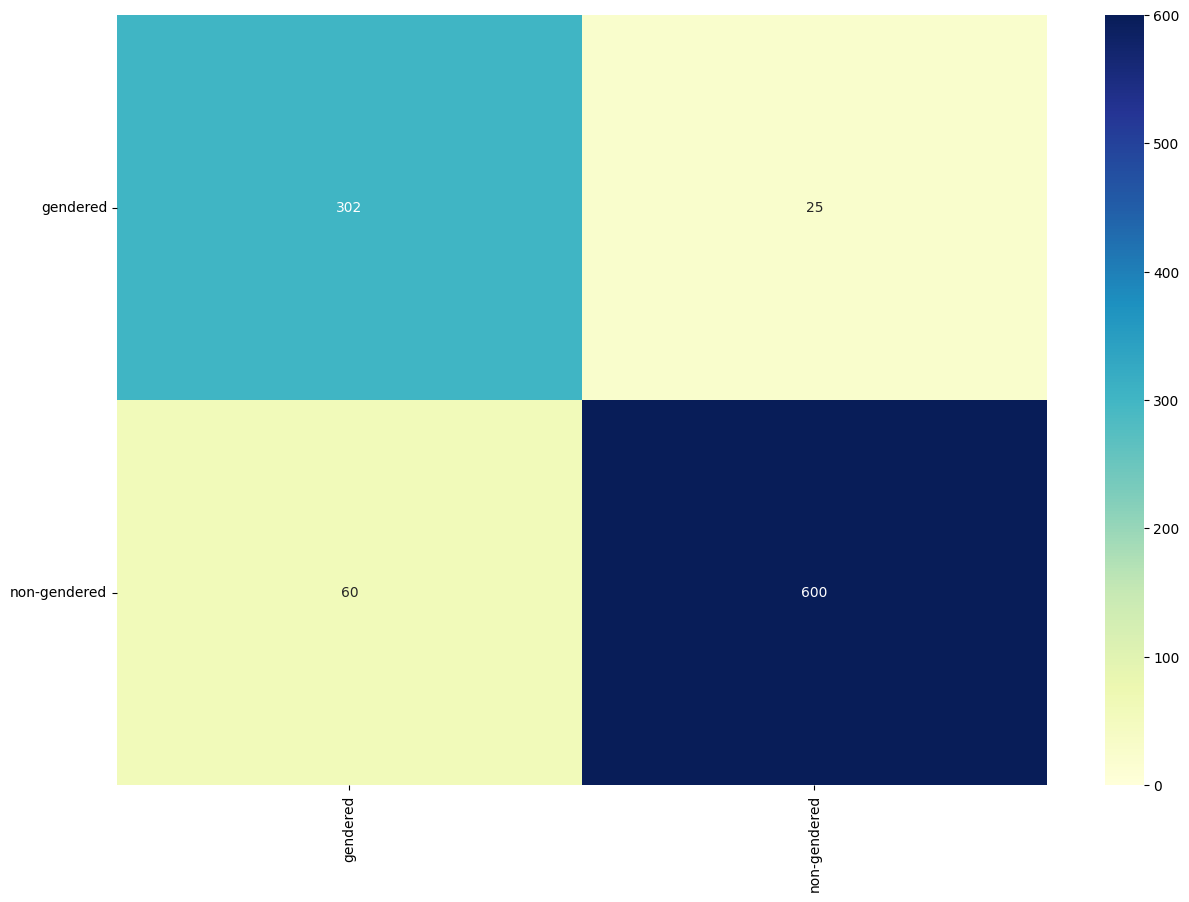

In [17]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, ada_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

The confusion matrix shows the number of abstracts that AdaBoost correctly and incorrectly classified as gendered and non-gendered research. For example, the model correctly classified 302 abstracts as gendered but incorrectly labeled 60 abstracts as gendered when they were actually non-gendered. Similarly, the model correctly classified 600 abstracts as non-gendered, while misclassifying 25 abstracts as non-gendered when they were in fact gendered.

## Supervised Machine Learning

Now, we will use the machine learning model that selected with AdaBoost Classifier to run on the data it has never seen to make predictions aka Supervised Machine Learning!

For this task, we will now upload new dataset with empty "code_choice" column.

In [18]:
url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-4/new-data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text # Store the raw CSV string

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

                                              AU   DE  \
0                      BARNETT C;A. J A;MONROE S  NaN   
1                DANCEY L;HENDERSON J;SHEAGLEY G  NaN   
2                      SHOUB K;STAUFFER K;SONG M  NaN   
3  DANCYGIER R;EGAMI N;JAMAL A;RISCHKE ;RAMONA R  NaN   
4                   CHOI D;POERTNER M;SAMBANIS N  NaN   

                                                  ID  \
0  GENDER; EMPLOYMENT; WORK; PARTICIPATION; DECIS...   
1  SOCIAL CONSTRUCTION; INCUMBENCY; ADVANTAGE; PA...   
2  REPRESENTATIVE BUREAUCRACY; UNDOING GENDER; PE...   
3                                                NaN   
4  IMPLICIT ASSOCIATION TEST; INTERGROUP CONTACT;...   

                                                  C1  \
0  BARNETT, C (CORRESPONDING AUTHOR), PRINCETON U...   
1  DANCEY, L (CORRESPONDING AUTHOR), WESLEYAN UNI...   
2  SHOUB, K (CORRESPONDING AUTHOR), UNIV SOUTH CA...   
3  DANCYGIER, R (CORRESPONDING AUTHOR), PRINCETON...   
4  CHOI, DD (CORRESPONDING AUTHOR), UNIV

In [19]:
text = new_data['AB']

In [20]:
text

,AB
0,DOES EARNING INCOME EMPOWER WOMEN IN PATRIARCH...
1,THIS STUDY OFFERS EXPERIMENTAL TESTS OF THE ``...
2,POLITICAL SCIENTISTS HAVE INCREASINGLY BEGUN T...
3,AS THE NUMBER OF REFUGEES RISES ACROSS THE WOR...
4,WHY DO NATIVE EUROPEANS DISCRIMINATE AGAINST M...
...,...
1474,"IN AN ERA OF INCREASINGLY PUBLIC DIPLOMACY, CO..."
1475,THIS ARTICLE INVESTIGATES HOW UNEMPLOYMENT RIS...
1476,POLICIES TO ADDRESS RECONCILIATION OF WORK AND...
1477,HOW DO AUTHORITARIAN STATES IMPLEMENT POLICIES...


Now, we will do text-preprocessing.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

## Predicting Features: Fitting New Dataset

Using the code below, we will use the AdaBoost Classifier to make predictions based on our previously trained machine learning model.

Here the `fit()` method trains the AdaBoost Classifier model using our training data:

- `dtm` represents the preprocessed training features. It's likely a Document-Term Matrix (DTM) or TF-IDF matrix generated from the text abstracts (X_train) during the text preprocessing steps.
- `y_train` is the corresponding target labels (e.g., 0 or 1 for 'non-gendered' or 'gendered' research) for each sample in dtm.

After this line executes, classifier holds the trained machine learning model, ready to make predictions.

In [23]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
classif = model.fit(dtm, y_train)

The next line of code preprocesses the 'Abstract' column (AB) from the `new_data` DataFrame so that it's in the same format as the data the model was trained on.

In [24]:
test_dtm = vect.transform(new_data['AB'])

Removing any empty values for abstracts

In [25]:
import pandas as pd

# Replace NaN values with an empty string before applying transform
new_data['AB'] = new_data['AB'].fillna('')
test_dtm = vect.transform(new_data['AB'])

Using the code below, we are making predictions using our machine learning model for the `code_choice` in our new dataset.

In [26]:
test = classif.predict(test_dtm)

Here, I am renaming the column from 0 -> code_choice.

In [27]:
df2 = pd.DataFrame(test)
df2.rename(columns={0: 'code_choice'}, inplace=True)

In [28]:
df2

,code_choice
0,1
1,0
2,1
3,1
4,1
...,...
1474,0
1475,0
1476,1
1477,0


You can see from above results that we have now successfully tagged each article based on the abstract as 1 (gendered) or 0 (non-gendered)!!

Let’s merge the metadata from the new_data file with the `code_choice` column from df2 into the original file that contains the empty column. This will allow us to reconstruct the complete dataset, which can then be shared with others or used for downstream analysis and processing.

In [29]:
new_data['code_choice'] = df2['code_choice']
combined_df = new_data

In [30]:
display(combined_df.head())

,AU,DE,ID,C1,CR,AB,DI,SN,JI,SO,...,AU_UN_NR,SR_FULL,SR,UID,gender_journ,auto_abs,code_choice,Abbreviation,Association,Year Founded
0,BARNETT C;A. J A;MONROE S,NaN,GENDER; EMPLOYMENT; WORK; PARTICIPATION; DECIS...,"BARNETT, C (CORRESPONDING AUTHOR), PRINCETON U...","AKTER S., 2005, JOURNAL OF DEVELOPING AREAS, V...",DOES EARNING INCOME EMPOWER WOMEN IN PATRIARCH...,10.1111/AJPS.12561,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"BARNETT C, 2021,","BARNETT C, 2021,",9329,0,0,1,AJPS,MPSA,1957
1,DANCEY L;HENDERSON J;SHEAGLEY G,NaN,SOCIAL CONSTRUCTION; INCUMBENCY; ADVANTAGE; PA...,"DANCEY, L (CORRESPONDING AUTHOR), WESLEYAN UNI...","ABRAMOWITZ AI, 2016, ELECT STUD, V41, P12, DOI...",THIS STUDY OFFERS EXPERIMENTAL TESTS OF THE ``...,10.1111/AJPS.12815,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"DANCEY L, 2023,","DANCEY L, 2023,",9330,0,0,0,AJPS,MPSA,1957
2,SHOUB K;STAUFFER K;SONG M,NaN,REPRESENTATIVE BUREAUCRACY; UNDOING GENDER; PE...,"SHOUB, K (CORRESPONDING AUTHOR), UNIV SOUTH CA...","ANONYMOUS, 2010, CRIM DAT BRIEF WOM L; BAUMGAR...",POLITICAL SCIENTISTS HAVE INCREASINGLY BEGUN T...,10.1111/AJPS.12618,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"SHOUB K, 2021,","SHOUB K, 2021,",9331,0,0,1,AJPS,MPSA,1957
3,DANCYGIER R;EGAMI N;JAMAL A;RISCHKE ;RAMONA R,NaN,NaN,"DANCYGIER, R (CORRESPONDING AUTHOR), PRINCETON...","ADIDA CL, 2014, IMMIGRANT EXCLUSION AND INSECU...",AS THE NUMBER OF REFUGEES RISES ACROSS THE WOR...,10.1111/AJPS.12595,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"DANCYGIER R, 2022,","DANCYGIER R, 2022,",9333,0,0,1,AJPS,MPSA,1957
4,CHOI D;POERTNER M;SAMBANIS N,NaN,IMPLICIT ASSOCIATION TEST; INTERGROUP CONTACT;...,"CHOI, DD (CORRESPONDING AUTHOR), UNIV PITTSBUR...","ADIDA CL, 2010, P NATL ACAD SCI USA, V107, P22...",WHY DO NATIVE EUROPEANS DISCRIMINATE AGAINST M...,10.1111/AJPS.12627,0092-5853,AM. J. POLIT. SCI.,AMERICAN JOURNAL OF POLITICAL SCIENCE,...,NaN,"CHOI D, 2023,","CHOI D, 2023,",9334,0,0,1,AJPS,MPSA,1957


Let's SAVE the combined data as a CSV file.

In [31]:
combined_df.to_csv('predicted_data.csv', index=False)